# PyRadtran Quickstart

Basic usage example demonstrating spectral radiative transfer from 400nm to 700nm simulations with xarray integration.

In [52]:
# Import PyRadtran components using NEW IO system
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
from matplotlib import cm


# Load the configuration from the YAML file
config_path = Path('../config/spectral_config.yaml')
import logging
# change to "DEBUG" if you want to see more output
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

N_timesteps = 10

# stationary simulation at constant altitude, latitude, and longitude but with varying time
ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2025-04-04T08:00:00', periods=N_timesteps, freq='h'),
        'latitude' : ('time', [61.0] * N_timesteps),
        'longitude' : ('time', [22.0] * N_timesteps),
        'altitude' : ('altitude', [0, 1, 5, 10, 25, 50, 100]),
    }
)

# Run a spectral simulation for a single point using NEW IO system
ds_sim = ds.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
)

print("\nSimulation complete with NEW IO system!")
print(f"Dataset variables: {list(ds_sim.data_vars.keys())}")
print(f"Dataset coordinates: {list(ds_sim.coords.keys())}")
print(f"Dataset shape: {ds_sim.dims}")

2025-07-22 03:10:02,390 - pyradtran.config - INFO - Loading configuration from: ../config/spectral_config.yaml
2025-07-22 03:10:02,403 - pyradtran.config - INFO - Configuration loaded successfully.



Simulation complete with NEW IO system!
Dataset variables: ['sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo']
Dataset coordinates: ['time', 'latitude', 'longitude', 'wavelength', 'altitude']
Dataset shape: FrozenMappingWarningOnValuesAccess({'time': 10, 'wavelength': 301, 'altitude': 7})


## Sanity Check


<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/projekt_agmwend/home_rad/Joshua/tmp/ipykernel_3108659/2336648239.py:19: SyntaxWarning: invalid escape sequence '\m'
  ax.set_zlabel('$F_\mathrm{dir}^\downarrow$ ($\mathrm{W \cdot m^{-2}}$)')


Text(0.5, 0, '$F_\\mathrm{dir}^\\downarrow$ ($\\mathrm{W \\cdot m^{-2}}$)')

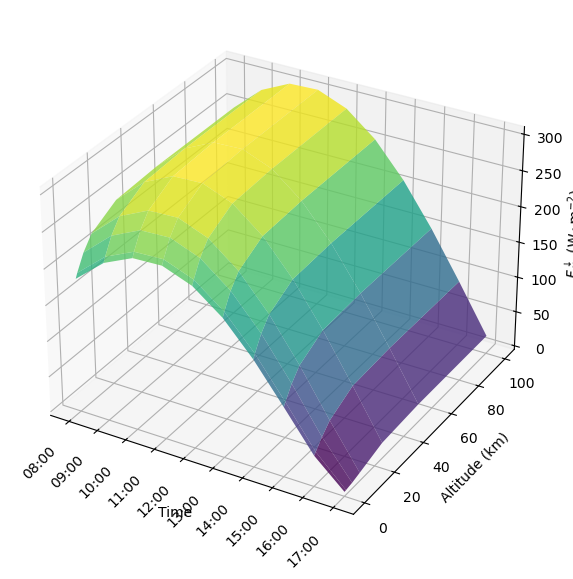

In [43]:
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': '3d'})

ax.set_prop_cycle(
    color=cm.viridis(np.linspace(0, 1, len(ds_sim['time'].values))),
)

# make a 3d plot with time on the x-axis, wavelength on the y-axis, and irradiance on the z-axis
x = np.arange(len(ds_sim['time'].values))
y = ds_sim['altitude'].values
z = ds_sim.integrate('wavelength')['edir'].T / 1000
X, Y = np.meshgrid(x, y)
ax.plot_surface(X, Y, z, cmap=cm.viridis, edgecolor='none', alpha=0.8)
# format x-axis as time
ax.set_xticks(x)
ax.set_xticklabels(ds_sim['time'].dt.strftime('%H:%M').values, rotation=45, ha='right')

ax.set_xlabel('Time')
ax.set_ylabel('Altitude (km)')
ax.set_zlabel('$F_\mathrm{dir}^\downarrow$ ($\mathrm{W \cdot m^{-2}}$)')


## Results

Visualization of spectral direct irradiance across wavelength at the first timestep.

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
/projekt_agmwend/home_rad/Joshua/tmp/ipykernel_3108659/4243175334.py:17: SyntaxWarning: invalid escape sequence '\m'
  ax.set_zlabel('$F_\mathrm{dir}^\downarrow$ ($\mathrm{W m^{-2}}$)')


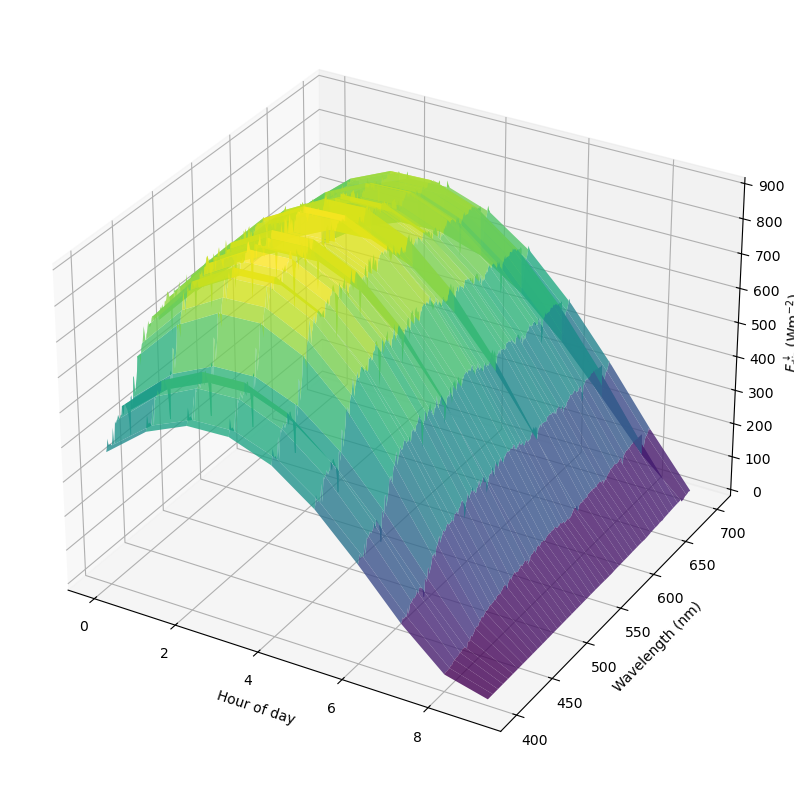

In [46]:

# make a 3d plot with time on the x-axis, wavelength on the y-axis, and irradiance on the z-axis
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.set_prop_cycle(
    color=cm.viridis(np.linspace(0, 1, len(ds_sim['wavelength'].values))),
)

x = np.arange(len(ds_sim['time'].values))
y = ds_sim['wavelength'].values
z = ds_sim.sel(altitude=0)['edir'].values.T
X, Y = np.meshgrid(x, y)

ax.plot_surface(X, Y, z, cmap=cm.viridis, edgecolor='none', alpha=0.8)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Wavelength (nm)')
ax.set_zlabel('$F_\mathrm{dir}^\downarrow$ ($\mathrm{W m^{-2}}$)')

plt.tight_layout()